# Workflow 1 — Mass-selected kNN sensitivity

Steps:
1. Generate kNN summaries for mass-selected BHs (multiple snapshots, multiple mass cuts)
2. Sensitivity sweep across **snapshots** (fixed mass cut)
3. Sensitivity sweep across **mass cuts** (fixed snapshot), with PCA

Shared "load -> residual -> sensitivity" logic lives in `src/analysis_pipeline.py`
so it isn't copy-pasted in every cell below.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.generate_knn import run_suite
from src.analysis_pipeline import sweep_sensitivity, load_and_analyze, DEFAULT_PARAMS

PARAMS_FILE = (
    "../CAMELS-master/docs/params/IllustrisTNG/"
    "CosmoAstroSeed_IllustrisTNG_L25n256_LH.txt"
)

## 1. Generate summaries

Set `GENERATE = False` once the .npz files already exist in `../outputs/`
to skip the (expensive) re-run.

In [7]:
GENERATE = True

SNAPSHOTS = [32, 50, 90]
MASS_CUTS = [1e6, 1e7, 1e8]

if GENERATE:
    # Default mass cut (1e6) across all snapshots
    for snap in SNAPSHOTS:
        run_suite(snap=snap)

    # Mass-cut sweep at snap=50 (1e6 already generated above)
    for mcut in MASS_CUTS:
        run_suite(snap=50, mcut=mcut)

Found 1000 files


100%|██████████| 1000/1000 [09:18<00:00,  1.79it/s]



Saved:
../outputs/knn_snap32_M1e+06.npz

Successful runs = 1000
Summary shape = (1000, 150)
Mean N_BH = 743.533
Found 1000 files


100%|██████████| 1000/1000 [10:07<00:00,  1.65it/s]



Saved:
../outputs/knn_snap50_M1e+06.npz

Successful runs = 1000
Summary shape = (1000, 150)
Mean N_BH = 1144.152
Found 1000 files


...


Saved:
../outputs/knn_snap50_M1e+06.npz

Successful runs = 1000
Summary shape = (1000, 150)
Mean N_BH = 1144.152
Found 1000 files


100%|██████████| 1000/1000 [05:31<00:00,  3.02it/s]



Saved:
../outputs/knn_snap50_M1e+07.npz

Successful runs = 943
Summary shape = (943, 150)
Mean N_BH = 83.53764581124072
Found 1000 files


100%|██████████| 1000/1000 [03:43<00:00,  4.48it/s]



Saved:
../outputs/knn_snap50_M1e+08.npz

Successful runs = 769
Summary shape = (769, 150)
Mean N_BH = 50.391417425227566


## 2. Sensitivity sweep across snapshots

Fixed mass cut (1e6), varying snapshot.

In [8]:
SNAP_SWEEP = [32, 50, 90]

snap_paths = [
    f"../outputs/knn_snap{snap}_M1e+06.npz"
    for snap in SNAP_SWEEP
]

df_snap = sweep_sensitivity(
    npz_paths=snap_paths,
    sweep_labels=SNAP_SWEEP,
    sweep_name="snap",
    params=DEFAULT_PARAMS,
    params_file=PARAMS_FILE,
)

df_snap

/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(
/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(
/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(


,snap,parameter,rms
0,32,Omega_m,0.016906
1,32,sigma_8,0.008919
2,32,A_SN1,0.003042
3,32,A_AGN1,0.003274
4,32,A_SN2,0.001778
5,32,A_AGN2,0.001532
6,50,Omega_m,0.007248
7,50,sigma_8,0.004922
8,50,A_SN1,0.004354
9,50,A_AGN1,0.002207


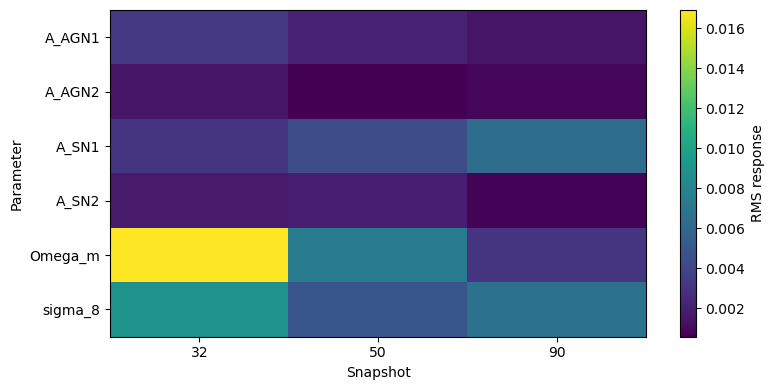

In [9]:
table_snap = df_snap.pivot(index="parameter", columns="snap", values="rms")

plt.figure(figsize=(8, 4))
im = plt.imshow(table_snap.values, aspect="auto")
plt.colorbar(im, label="RMS response")
plt.yticks(np.arange(len(table_snap.index)), table_snap.index)
plt.xticks(np.arange(len(table_snap.columns)), table_snap.columns)
plt.xlabel("Snapshot")
plt.ylabel("Parameter")
plt.tight_layout()
plt.show()

## 3. Sensitivity sweep across mass cuts (snap=50), with PCA

Fixed snapshot (50), varying mass cut. Also reports the PC1 explained
variance fraction for each mass cut as a quick check on how much the
clustering signal compresses into the leading PCA mode.

In [10]:
mcut_paths = [
    f"../outputs/knn_snap50_M{mcut:.0e}.npz"
    for mcut in MASS_CUTS
]

pc1_explained = {}
mcut_rows = []

for path, mcut in zip(mcut_paths, MASS_CUTS):
    result = load_and_analyze(
        path,
        params=DEFAULT_PARAMS,
        params_file=PARAMS_FILE,
        run_pca_flag=True,
    )
    pc1_explained[mcut] = result["explained"][0]
    for _, row in result["sensitivity"].iterrows():
        mcut_rows.append({
            "Mcut": mcut,
            "parameter": row["parameter"],
            "rms": row["rms"],
        })

df_mcut = pd.DataFrame(mcut_rows)

print("PC1 explained variance by mass cut:")
for mcut, val in pc1_explained.items():
    print(f"  M={mcut:.0e}  PC1={val:.4f}")

df_mcut

/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(
/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(


PC1 explained variance by mass cut:
  M=1e+06  PC1=0.5675
  M=1e+07  PC1=0.5488
  M=1e+08  PC1=0.5518


/home/jovyan/home/notebooks/../src/parameter_sensitivity.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  params = pd.read_csv(


,Mcut,parameter,rms
0,1000000.0,Omega_m,0.007248
1,1000000.0,sigma_8,0.004922
2,1000000.0,A_SN1,0.004354
3,1000000.0,A_AGN1,0.002207
4,1000000.0,A_SN2,0.001911
5,1000000.0,A_AGN2,0.000566
6,10000000.0,Omega_m,0.011118
7,10000000.0,sigma_8,0.011044
8,10000000.0,A_SN1,0.007181
9,10000000.0,A_AGN1,0.001897


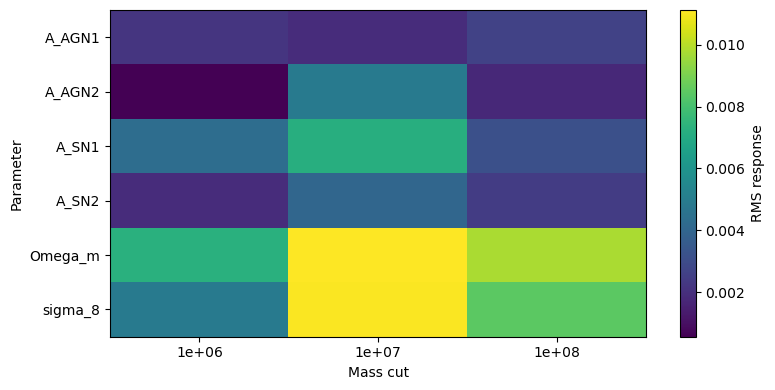

In [11]:
table_mcut = df_mcut.pivot(index="parameter", columns="Mcut", values="rms")

plt.figure(figsize=(8, 4))
im = plt.imshow(table_mcut.values, aspect="auto")
plt.colorbar(im, label="RMS response")
plt.yticks(np.arange(len(table_mcut.index)), table_mcut.index)
plt.xticks(np.arange(len(table_mcut.columns)), [f"{c:.0e}" for c in table_mcut.columns])
plt.xlabel("Mass cut")
plt.ylabel("Parameter")
plt.tight_layout()
plt.show()